### 2. Загрузка данных

Найдено файлов: 2
  C:\khoroshist\system-modeling\2_queue_of_car\results.csv
  C:\khoroshist\system-modeling\1_queue_of_car\khoroshistNew\results.csv

Читаем C:\khoroshist\system-modeling\2_queue_of_car\results.csv...

Читаем C:\khoroshist\system-modeling\1_queue_of_car\khoroshistNew\results.csv...

Собрано 12 параметров из 2 файлов
p_service: [0.7168141592920354, 0.701]
p_reject: [0.25663716814159293, 0.299]
p_busy_ko1: [0.224954333283238, 0.883077]
p_busy_ko2: [0.675700674593428, 0.605015]
n_columns_avg: [1.576355682470094, 2.093107]
p_idle_ko1: [0.1982405885057642, 0.262604]
p_idle_ko2: [0.22540372902414174, 0.249303]
r_avg: [0.6290888528941371, 0.310416]
t_wait_avg: [0.08888481996107055, 0.115906]
t_service_avg: [0.2227254391591376, 0.236205]
t_system_avg: [0.3116102591202081, 0.285478]
n_avg: [2.205444535364231, 1.798508]


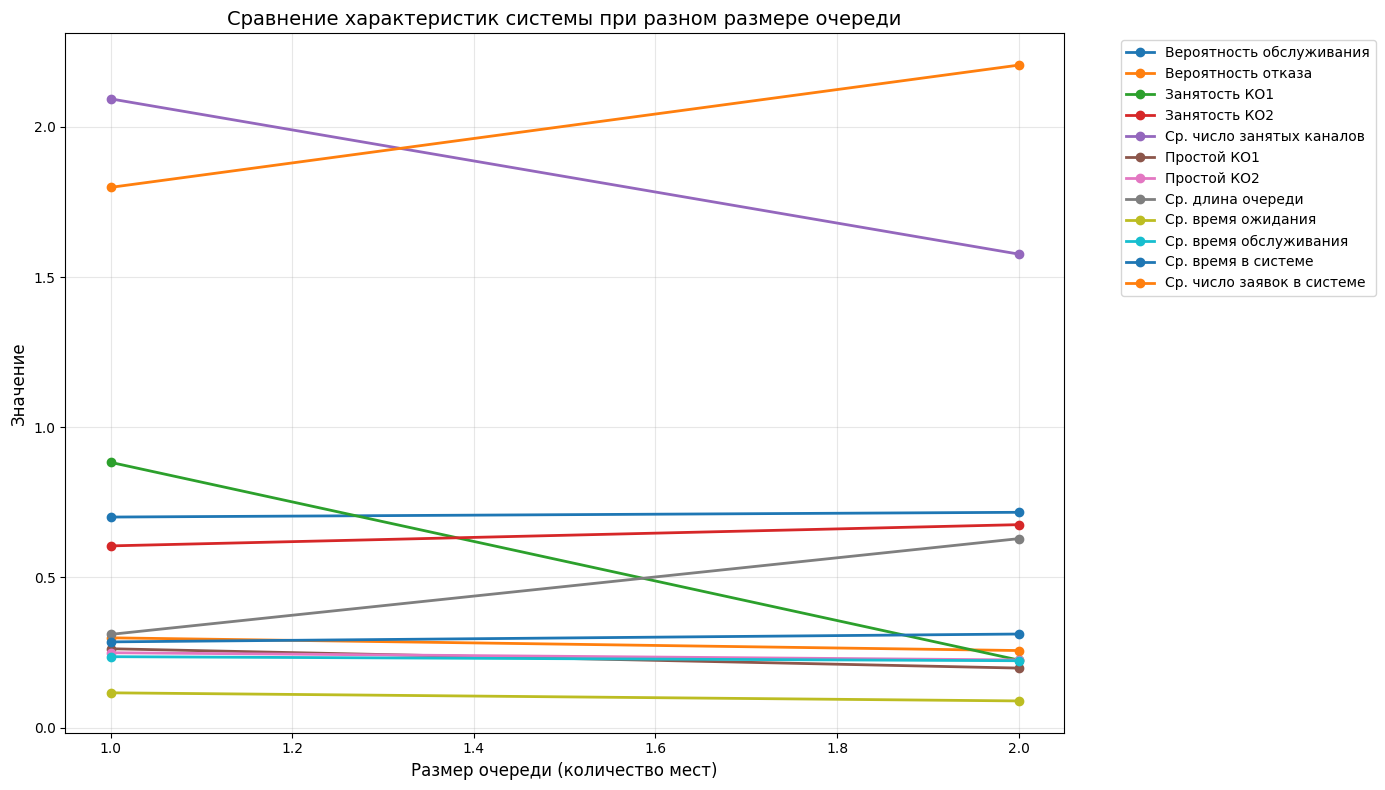

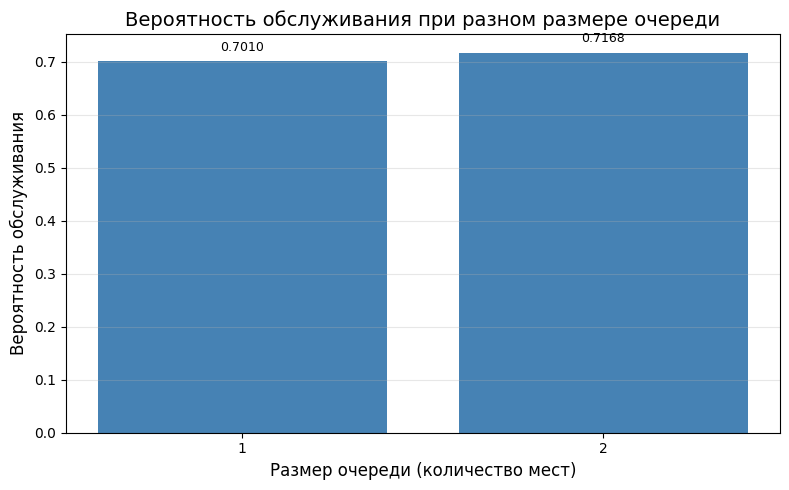

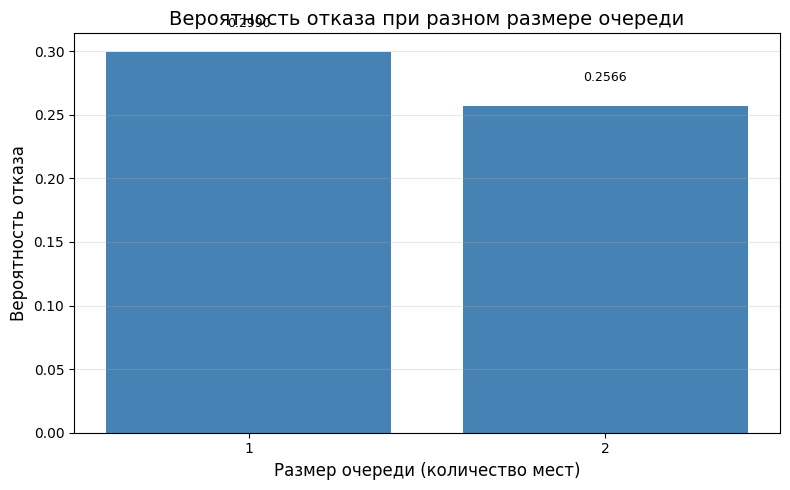

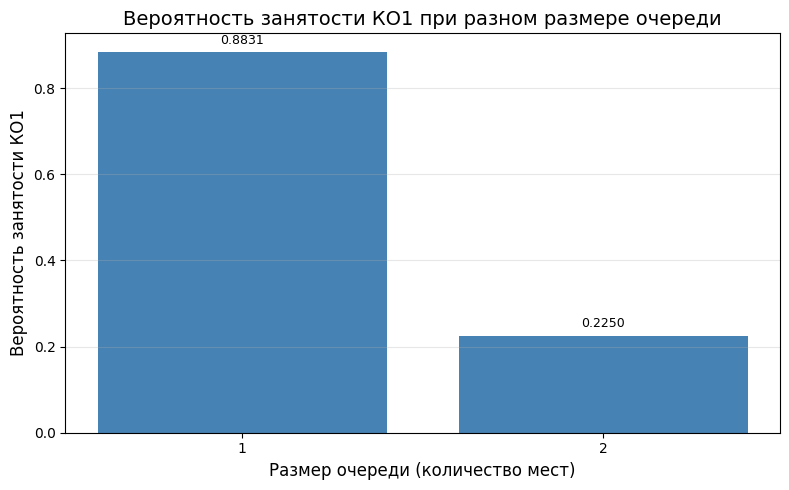

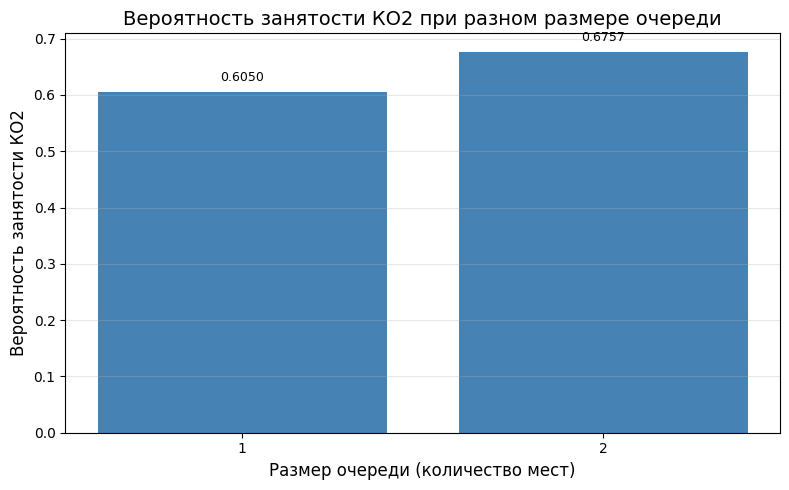

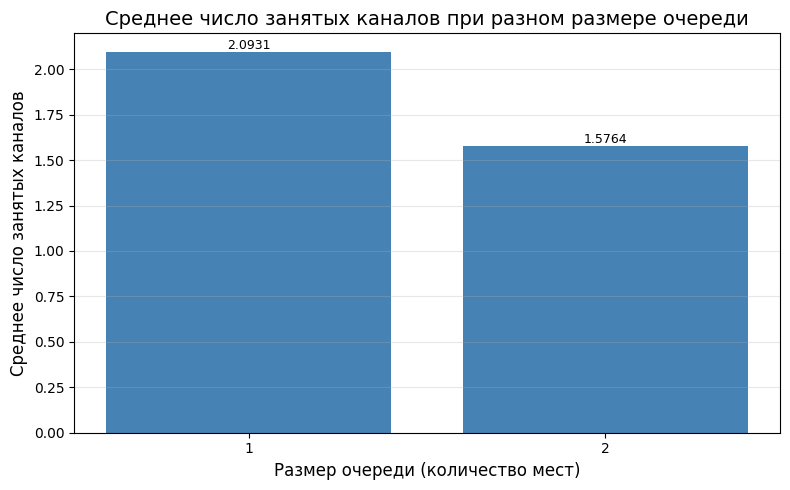

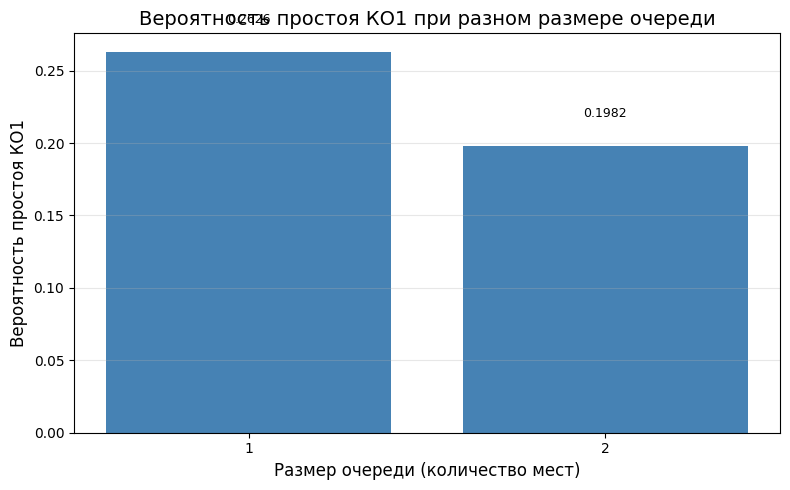

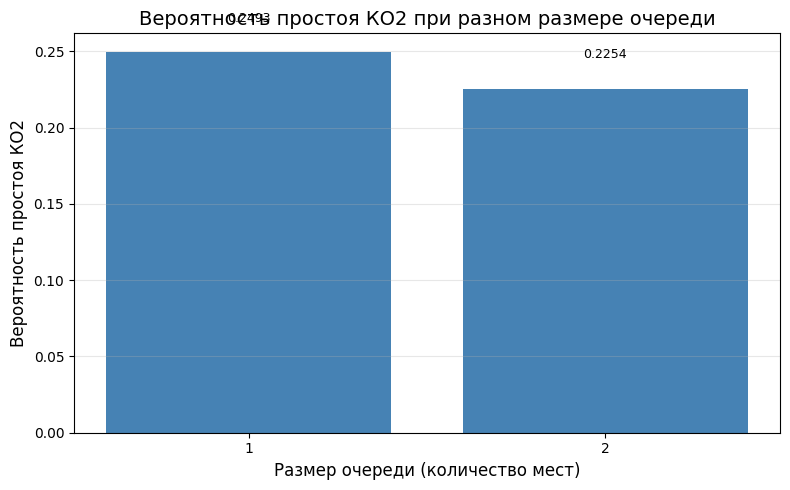

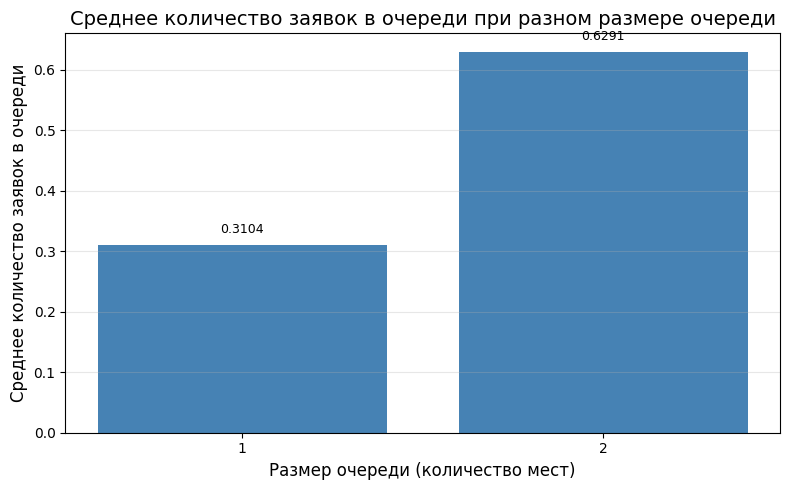

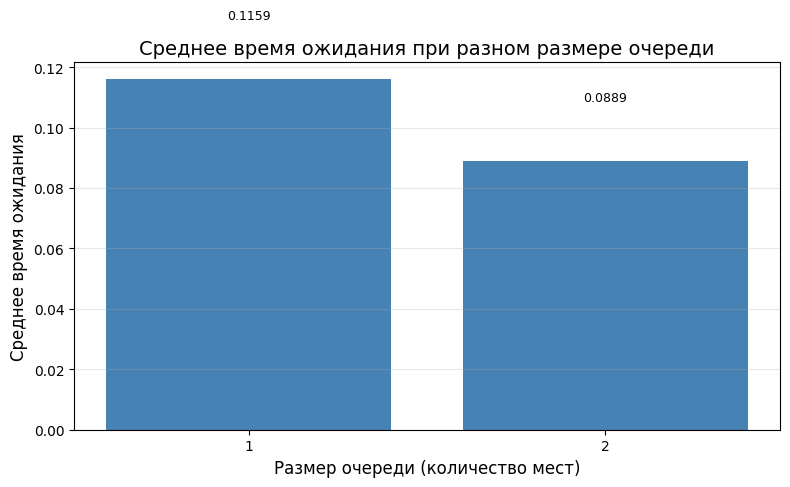

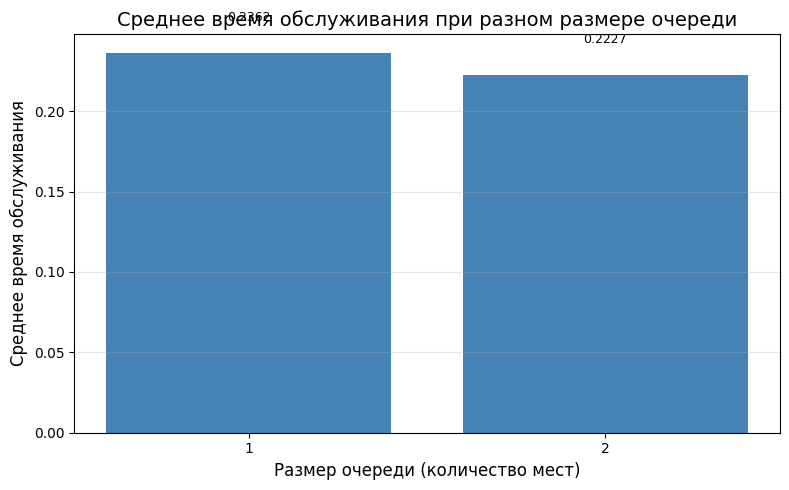

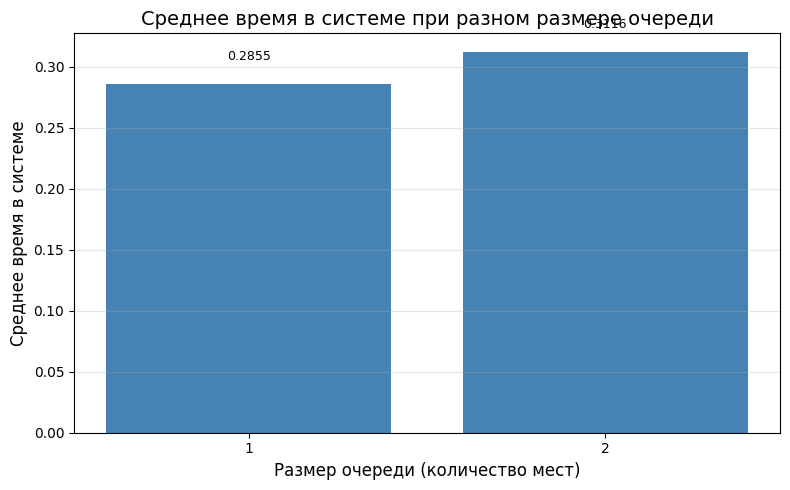

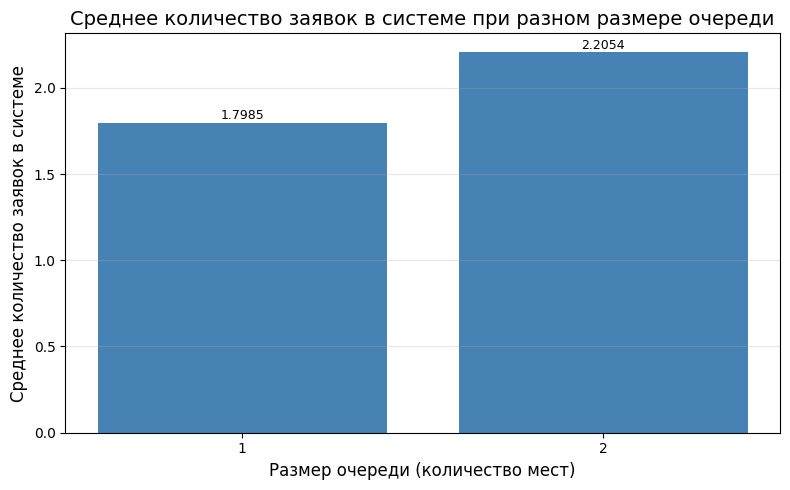


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Параметр                       1           2
----------------------------------------------------------------------
Вероятность обслуживания      0.7010      0.7168
Вероятность отказа        0.2990      0.2566
Вероятность занятости КО1      0.8831      0.2250
Вероятность занятости КО2      0.6050      0.6757
Среднее число занятых каналов      2.0931      1.5764
Вероятность простоя КО1      0.2626      0.1982
Вероятность простоя КО2      0.2493      0.2254
Среднее количество заявок в очереди      0.3104      0.6291
Среднее время ожидания      0.1159      0.0889
Среднее время обслуживания      0.2362      0.2227
Среднее время в системе      0.2855      0.3116
Среднее количество заявок в системе      1.7985      2.2054


In [1]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path

FILENAME = "results.csv"
BASE_DIR = Path.cwd()

def find_all_csv_files(base_dir, filename):
    """Рекурсивно ищет все файлы results.csv во всех подпапках"""
    found_files = []
    for path in base_dir.rglob(filename):  # rglob - рекурсивный поиск
        found_files.append(path)
    return found_files

def get_data_csv(path):
    """Чтение CSV файла"""
    if not path.exists():
        return {}
    try:
        with open(path, "r", newline="", encoding="utf-8") as file:
            reader = csv.reader(file)
            next(reader)  # Пропускаем заголовок
            return {row[0]: float(row[1]) for row in reader}
    except Exception as e:
        print(f"Ошибка работы с файлом {path}. {e}")
        return {}

# Ищем все results.csv
all_files = find_all_csv_files(BASE_DIR, FILENAME)
print(f"Найдено файлов: {len(all_files)}")
for f in all_files:
    print(f"  {f}")

# Собираем данные из всех найденных файлов
data = {}
file_count = 0

for file_path in all_files:
    file_count += 1
    print(f"\nЧитаем {file_path}...")
    data_queue = get_data_csv(file_path)
    
    for key, value in data_queue.items():
        if key not in data:
            data[key] = [value]
        else:
            data[key].append(value)

print(f"\nСобрано {len(data)} параметров из {file_count} файлов")

# Выводим значения
for key, values in data.items():
    print(f"{key}: {values}")

# Создаем список размеров очереди из имен папок
# (пытаемся извлечь число из пути)
queue_sizes = []
for file_path in all_files:
    # Ищем число в имени папки
    parts = file_path.parts
    queue_size = None
    for part in parts:
        if '_queue_of_car' in part:
            # Извлекаем число перед _queue_of_car
            num_part = part.split('_')[0]
            if num_part.isdigit():
                queue_size = int(num_part)
                break
    if queue_size is None:
        queue_size = len(queue_sizes)  # если не нашли, используем индекс
    queue_sizes.append(queue_size)

# Сортируем данные по размеру очереди
if queue_sizes:
    # Создаем список индексов для сортировки
    sorted_indices = sorted(range(len(queue_sizes)), key=lambda i: queue_sizes[i])
    
    # Сортируем queue_sizes
    queue_sizes_sorted = [queue_sizes[i] for i in sorted_indices]
    
    # Сортируем значения для каждого параметра
    for key in data:
        data[key] = [data[key][i] for i in sorted_indices]

# Построение всех графиков на одном рисунке
if data and queue_sizes:
    plt.figure(figsize=(14, 8))
    
    names = {
        'a': 'Пропускная способность',
        'p_service': 'Вероятность обслуживания',
        'p_reject': 'Вероятность отказа',
        'p_busy_ko1': 'Занятость КО1',
        'p_busy_ko2': 'Занятость КО2',
        'n_columns_avg': 'Ср. число занятых каналов',
        'p_idle_ko1': 'Простой КО1',
        'p_idle_ko2': 'Простой КО2',
        'r_avg': 'Ср. длина очереди',
        't_wait_avg': 'Ср. время ожидания',
        't_service_avg': 'Ср. время обслуживания',
        't_system_avg': 'Ср. время в системе',
        'n_avg': 'Ср. число заявок в системе'
    }
    
    for key, values in data.items():
        label = names.get(key, key)
        plt.plot(queue_sizes_sorted, values, marker='o', linewidth=2, markersize=6, label=label)
    
    plt.xlabel('Размер очереди (количество мест)', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.title('Сравнение характеристик системы при разном размере очереди', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Отдельные графики для каждого параметра
for key, values in data.items():
    plt.figure(figsize=(8, 5))
    
    names = {
        'a': 'Пропускная способность',
        'p_service': 'Вероятность обслуживания',
        'p_reject': 'Вероятность отказа',
        'p_busy_ko1': 'Вероятность занятости КО1',
        'p_busy_ko2': 'Вероятность занятости КО2',
        'n_columns_avg': 'Среднее число занятых каналов',
        'p_idle_ko1': 'Вероятность простоя КО1',
        'p_idle_ko2': 'Вероятность простоя КО2',
        'r_avg': 'Среднее количество заявок в очереди',
        't_wait_avg': 'Среднее время ожидания',
        't_service_avg': 'Среднее время обслуживания',
        't_system_avg': 'Среднее время в системе',
        'n_avg': 'Среднее количество заявок в системе'
    }
    
    title = names.get(key, key)
    plt.bar([str(q) for q in queue_sizes_sorted], values, color='steelblue')
    plt.xlabel('Размер очереди (количество мест)', fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.title(f'{title} при разном размере очереди', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения над столбцами
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Вывод сводной таблицы
print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)
print(f"{'Параметр':<20}", end="")
for q in queue_sizes_sorted:
    print(f"{q:>12}", end="")
print()
print("-"*70)

for key, values in data.items():
    name = names.get(key, key)
    print(f"{name:<20}", end="")
    for v in values:
        print(f"{v:12.4f}", end="")
    print()